In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

## Data Merge

In [3]:
data_2014 = pd.read_csv("../data/output/data-2014.csv")
data_2015 = pd.read_csv("../data/output/data-2015.csv")
data_2016 = pd.read_csv("../data/output/data-2016.csv")
data_2017 = pd.read_csv("../data/output/data-2017.csv")
data_2018 = pd.read_csv("../data/output/data-2018.csv")
data_2019 = pd.read_csv("../data/output/data-2019.csv")

In [4]:
data_2014["year"] = 2014
data_2015["year"] = 2015
data_2016["year"] = 2016
data_2017["year"] = 2017
data_2018["year"] = 2018
data_2019["year"] = 2019

In [5]:
data = pd.concat([data_2014, data_2015, data_2016, data_2017, data_2018, data_2019], ignore_index=True)

## Question 1

In [6]:
question_1 = data[
    (data["snp"] != "Yes") &
    ~((data["planid"] >= 800) & (data["planid"] < 900)) & 
    ~ (data["payment_partc"].isna())].copy()
question_1.head(10)

,contractid,planid,fips,year,n_nonmiss,avg_enrollment,sd_enrollment,min_enrollment,max_enrollment,first_enrollment,...,costsharing_partd,riskscore_partd,parta_enroll,parta_reimb,partb_enroll,partb_reimb,mean_risk,year_ffs,basic_premium,bid
2,H0028,2.0,19153.0,2014,2,347.0,1.414214,346.0,348.0,346.0,...,37.09,0.910,46091.0,138761798.0,41137.0,146914297.0,0.936,2014.0,0.0,806.179654
3,H0028,3.0,19155.0,2014,2,173.0,11.313708,165.0,181.0,165.0,...,37.96,0.983,10934.0,38584530.0,10013.0,40401051.0,0.954,2014.0,0.0,844.788274
4,H0028,4.0,15003.0,2014,2,1019.5,20.506097,1005.0,1034.0,1034.0,...,14.16,0.829,76625.0,198161786.0,59102.0,182990122.0,0.833,2014.0,0.0,861.327751
5,H0028,4.0,15007.0,2014,2,177.0,25.455844,159.0,195.0,159.0,...,14.16,0.829,6730.0,17199086.0,5473.0,16635989.0,0.795,2014.0,0.0,861.327751
6,H0028,4.0,15009.0,2014,2,238.5,23.334524,222.0,255.0,222.0,...,14.16,0.829,10725.0,27670770.0,8246.0,25732595.0,0.811,2014.0,0.0,861.327751
7,H0028,5.0,15003.0,2014,2,234.5,20.506097,220.0,249.0,220.0,...,25.02,0.748,76625.0,198161786.0,59102.0,182990122.0,0.833,2014.0,0.0,1105.498534
8,H0028,5.0,15007.0,2014,2,30.0,8.485281,24.0,36.0,24.0,...,25.02,0.748,6730.0,17199086.0,5473.0,16635989.0,0.795,2014.0,0.0,1105.498534
9,H0028,5.0,15009.0,2014,2,87.5,10.606602,80.0,95.0,80.0,...,25.02,0.748,10725.0,27670770.0,8246.0,25732595.0,0.811,2014.0,0.0,1105.498534
10,H0084,1.0,17001.0,2014,2,24.0,1.414214,23.0,25.0,23.0,...,17.48,0.816,10776.0,43159764.0,10103.0,45642370.0,1.011,2014.0,0.0,818.390663
11,H0084,1.0,17005.0,2014,2,14.0,0.000000,14.0,14.0,14.0,...,17.48,0.816,2343.0,9365608.0,2226.0,10129565.0,1.023,2014.0,0.0,818.390663


In [7]:
plan_counts = (
    question_1
    .groupby(["year", "fips"])["planid"]
    .nunique()
    .reset_index(name="num_unique_plans")
)
plan_counts.head()

,year,fips,num_unique_plans
0,2014,1001.0,9
1,2014,1003.0,19
2,2014,1005.0,8
3,2014,1007.0,6
4,2014,1009.0,9


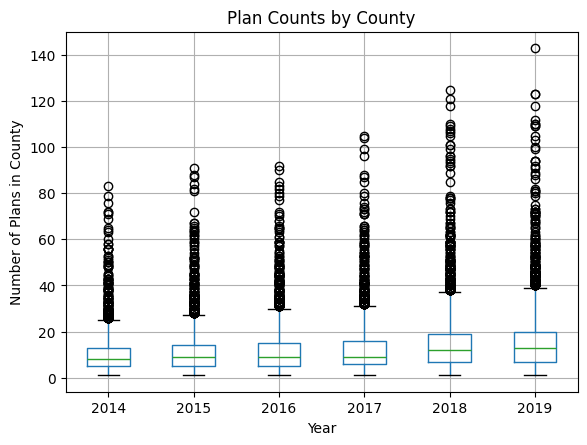

In [9]:
plan_counts.boxplot(column="num_unique_plans", by="year")

plt.title("Plan Counts by County")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Number of Plans in County")
plt.show()

#### Interpretation: The plot shows the number of Medicare Advantage plans available per county increases from 2014 to 2019. Thus, the number of plans seems sufficient enough to provide meaningful beneficiary choice.

## Question 2

In [10]:
data_2014 = (
question_1[question_1["year"] == 2014]
.dropna(subset=["bid"])
)

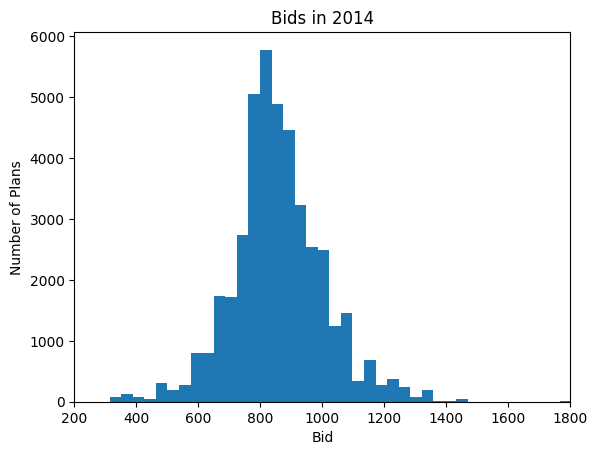

In [11]:
plt.hist(data_2014.bid, bins=40)
plt.xlim(200, 1800)
plt.xlabel("Bid")
plt.ylabel("Number of Plans")
plt.title("Bids in 2014")
plt.show()

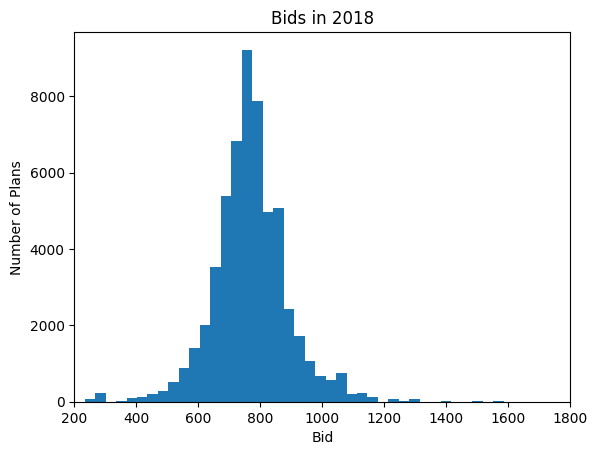

In [12]:
plt.hist(question_1[question_1["year"] == 2018].bid, bins=40)
plt.xlim(200, 1800)
plt.xlabel("Bid")
plt.ylabel("Number of Plans")
plt.title("Bids in 2018")
plt.show()

#### Interpretation: From 2014 to 2018, the distribution of plan bids appeared to shift slightly downward and became more concentrated. In 2014, there is more variation in bids and more high-bid outliers. By 2018, however, bids are more tightly clustered around the median value.

## Question 3

In [31]:
data_clean = data[
    (data["snp"] != "Yes") &
    ~((data["planid"] >= 800) & (data["planid"] < 900)) &
    (data["payment_partc"].notna())
].copy()

hhi_county = (
    data_clean
    .groupby(["fips", "year"])
    .apply(lambda g: np.nansum(((g["avg_enrollment"] / g["avg_enrolled"].iloc[0]) * 100)**2))
    .reset_index(name="hhi")
)

avg_hhi = (
    hhi_county.groupby("year", as_index=False)["hhi"].mean()
)

avg_hhi

/tmp/ipykernel_265252/385004567.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.nansum(((g["avg_enrollment"] / g["avg_enrolled"].iloc[0]) * 100)**2))


,year,hhi
0,2014,1567.400366
1,2015,1472.516289
2,2016,1431.496730
3,2017,1320.318401
4,2018,1220.415811
5,2019,1074.056731


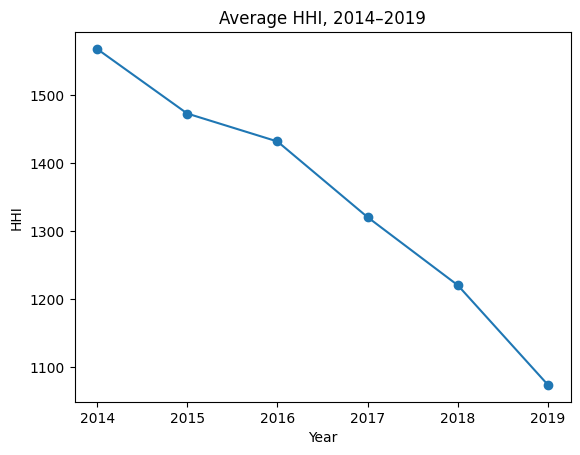

In [32]:
plt.figure()
plt.plot(avg_hhi["year"], avg_hhi["hhi"], marker="o")
plt.xlabel("Year")
plt.ylabel("HHI")
plt.title("Average HHI, 2014–2019")
plt.show()

#### Interpretation: The average HHI for MA markets declined from 2014 to 2019, which would suggest Medicare Advantage markets likely became more competitive over time.

## Question 4

In [36]:
county_year = (
    question_1[["fips", "year", "avg_enrolled", "avg_eligibles"]]
    .drop_duplicates()
    .dropna(subset=["avg_enrolled", "avg_eligibles"])
)

avg_ma_share = (
    county_year
    .groupby("year", as_index=False)
    .agg(
        enrolled=("avg_enrolled", "sum"),
        eligibles=("avg_eligibles", "sum"),
    )
)

avg_ma_share["ma_share"] = avg_ma_share["enrolled"] / avg_ma_share["eligibles"]

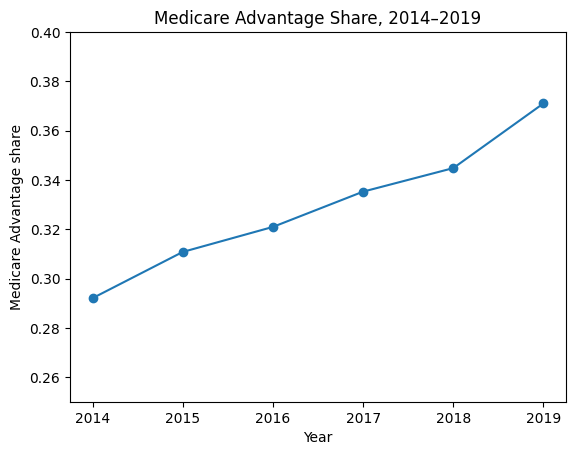

In [37]:
plt.figure()
plt.plot(avg_ma_share["year"], avg_ma_share["ma_share"], marker="o")
plt.xlabel("Year")
plt.ylabel("Medicare Advantage share")
plt.title("Medicare Advantage Share, 2014–2019")
plt.ylim(0.25, 0.4)
plt.show()

#### Interpretation: The average share of Medicare beneficiaries enrolled in Medicare Advantage have steadily increased from 2014 to 2019, which indicates that Medicare Advantage became more popular over time.

## Question 5

In [38]:
data_2018 = data[data['year'] == 2018].copy()

In [39]:
hhi_2018 = hhi_county[hhi_county['year'] == 2018].copy()

In [40]:
hhi_33 = hhi_2018['hhi'].quantile(0.33)
hhi_66 = hhi_2018['hhi'].quantile(0.66)

hhi_33, hhi_66

(np.float64(542.0326897546498), np.float64(1291.847867881609))

In [41]:
hhi_2018['market_type'] = 'middle'

hhi_2018.loc[hhi_2018['hhi'] <= hhi_33, 'market_type'] = 'competitive'
hhi_2018.loc[hhi_2018['hhi'] >= hhi_66, 'market_type'] = 'uncompetitive'

In [44]:
data_2018 = data_2018.merge(
    hhi_2018[['fips', 'market_type']],
    on='fips',
    how='left'
)

In [45]:
data_2018 = data_2018[data_2018['market_type'].isin(['competitive', 'uncompetitive'])]

In [46]:
avg_bid = (
    data_2018.groupby('market_type')['bid']
        .mean()
        .reset_index()
)

avg_bid

,market_type,bid
0,competitive,782.386470
1,uncompetitive,762.791385


#### Interpretation: The average bid is slightly higher in competitive markets than in uncompetitive markets. This could be because plan-level averaging gives more weight to markets with more plans.

## Question 6

In [90]:
data_2018 = data[data['year'] == 2018].copy()

In [91]:
data_2018['ffs_cost'] = (
    (data_2018['parta_reimb'] + data_2018['partb_reimb']) /
    (data_2018['parta_enroll'] + data_2018['partb_enroll'])
)

In [92]:
ffs_2018 = (
    data_2018[['ssa','ffs_cost']]
    .drop_duplicates()
    .copy()
)

In [93]:
ffs_2018['ffs_quartile'] = pd.qcut(
    ffs_2018['ffs_cost'],
    4,
    labels=[1,2,3,4],
    duplicates='drop'
)

In [94]:
for q in [1,2,3,4]:
    ffs_2018[f'ffs_q{q}'] = (ffs_2018['ffs_quartile'] == q).astype(int)

In [97]:
data_2018 = data_2018.merge(
    hhi_2018[['fips', 'hhi', 'market_type']],
    on='fips',
    how='left'
)

data_2018 = data_2018[data_2018['market_type'].isin(['competitive', 'uncompetitive'])]

In [98]:
avg_bid_quartile = (
    data_2018
    .groupby(['ffs_quartile','market_type'])['bid']
    .mean()
    .reset_index()
    .pivot(index='ffs_quartile', columns='market_type', values='bid')
    .reset_index()
)

avg_bid_quartile

/tmp/ipykernel_265252/643183586.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['ffs_quartile','market_type'])['bid']


market_type,ffs_quartile,competitive,uncompetitive
0,1,801.479276,777.724086
1,2,794.925747,766.176158
2,3,775.653118,748.280886
3,4,769.766306,754.172241


## Question 7

In [102]:
clean_2018 = data[data["year"] == 2018].copy()

clean_2018 = clean_2018[
    (clean_2018["snp"] != "Yes") &
    ~((clean_2018["planid"] >= 800) & (clean_2018["planid"] < 900)) &
    (clean_2018["payment_partc"].notna())
].copy()

import numpy as np
clean_2018["ffs_cost"] = (
    (clean_2018["parta_reimb"] + clean_2018["partb_reimb"]) /
    (clean_2018["parta_enroll"] + clean_2018["partb_enroll"])
)

print("ffs_cost in clean_2018?", "ffs_cost" in clean_2018.columns)

ffs_cost in clean_2018? True


In [103]:
def summarize_fips(group: pd.DataFrame) -> pd.Series:
    total_enroll = pd.to_numeric(group["avg_enrolled"], errors="coerce").iloc[0]
    plan_enroll = pd.to_numeric(group["avg_enrollment"], errors="coerce")

    ma_share = np.where(
        total_enroll > 0,
        (plan_enroll / total_enroll) * 100,
        np.nan,
    )

    hhi_ma = np.nansum(ma_share ** 2)
    if np.all(np.isnan(ma_share)):
        hhi_ma = np.nan

    plan_count = group[["contractid", "planid"]].drop_duplicates().shape[0]
    avg_premium_partc = group["premium_partc"].mean(skipna=True)
    share_pos_premiums = (group["premium_partc"] > 0).mean()
    avg_bid = group["bid"].mean(skipna=True)
    avg_eligibles = group["avg_eligibles"].iloc[0]
    ffs_cost = group["ffs_cost"].iloc[0]

    return pd.Series(
        dict(
            hhi_ma=hhi_ma,
            plan_count=plan_count,
            avg_premium_partc=avg_premium_partc,
            share_pos_premiums=share_pos_premiums,
            avg_bid=avg_bid,
            avg_eligibles=avg_eligibles,
            ffs_cost=ffs_cost,
        )
    )

question_7 = (
    clean_2018
    .groupby("fips", as_index=False)
    .apply(summarize_fips)
    .reset_index(drop=True)
)

q_hhi_py = question_7["hhi_ma"].quantile([0.33, 0.66])
low_q, high_q = q_hhi_py.loc[0.33], q_hhi_py.loc[0.66]

lp_df = question_7.copy()

lp_df["treated_dummy"] = np.where(
    lp_df["hhi_ma"] >= high_q, 1,
    np.where(lp_df["hhi_ma"] <= low_q, 0, np.nan)
)

lp_df = lp_df.dropna(subset=["treated_dummy"])
lp_df = lp_df.dropna(subset=["ffs_cost"])

lp_df["ffs_q"] = pd.qcut(
    lp_df["ffs_cost"],
    4,
    labels=[1, 2, 3, 4]
).astype(int)

ffs_dummies = pd.get_dummies(lp_df["ffs_q"], prefix="q", drop_first=True)
lp_df = pd.concat([lp_df, ffs_dummies], axis=1)

lp_vars = lp_df[
    ["avg_bid", "treated_dummy", "q_2", "q_3", "q_4"]
].dropna().copy()

lp_covs = lp_vars[["q_2", "q_3", "q_4"]].copy()
lp_vars["treated_dummy"] = lp_vars["treated_dummy"].astype(int)

/tmp/ipykernel_265252/1731376503.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_fips)


In [104]:
!pip install rpy2


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [106]:
%load_ext rpy2.ipython

In [109]:
%%R
install.packages("Matching", repos="https://cloud.r-project.org")

* installing *source* package ‘Matching’ ...
** package ‘Matching’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘x86_64-conda-linux-gnu-cc (Anaconda gcc) 11.2.0’
using C++ compiler: ‘x86_64-conda-linux-gnu-c++ (Anaconda gcc) 11.2.0’


x86_64-conda-linux-gnu-cc -I"/local/5261/econ470001/conda-env-py313/lib/R/include" -DNDEBUG -DR_BUILD -DR_NO_REMAP  -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /local/5261/econ470001/conda-env-py313/include -I/local/5261/econ470001/conda-env-py313/include -Wl,-rpath-link,/local/5261/econ470001/conda-env-py313/lib   -DR_BUILD -fpic  -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /local/5261/econ470001/conda-env-py313/include -fdebug-prefix-map=/croot/r-base_1744617423037/work=/usr/local/src/conda/r-base-4.3.1 -fdebug-prefix-map=/local/5261/econ470001/conda-env-py313=/usr/local/src/conda-prefix  -c cblas_dasum.c -o cblas_dasum.o
x86_64-conda-linux-gnu-cc -I"/local/5261/econ470001/conda-env-py313/lib/R/include" -DNDEBUG -DR_BUILD -DR_NO_REMAP  -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /local/5261/econ470001/conda-env-py313/include -I/local/5261/econ470001/conda-env-py313/include -Wl,-rpath-link,/local/5261/econ470

installing to /home/gdanzil/R/x86_64-conda-linux-gnu-library/4.3/00LOCK-Matching/00new/Matching/libs
** R
** data
** demo
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (Matching)


Installing package into ‘/home/gdanzil/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/Matching_4.10-15.tar.gz'
Content type 'application/x-gzip' length 254274 bytes (248 KB)
downloaded 248 KB


The downloaded source packages are in
	‘/tmp/Rtmp2gWgkz/downloaded_packages’


In [110]:
%%R -i lp_vars -i lp_covs -o ate_raw -o se_raw

library(Matching)

m.nn.var2 <- Matching::Match(
    Y = lp_vars$avg_bid,
    Tr = lp_vars$treated_dummy,
    X = lp_covs,
    M = 1,
    Weight = 1,
    estimand = "ATE"
)

cat("NN (Weight=1, M=1), ATE:", m.nn.var2$est[1], "\n")

summary(m.nn.var2)

ate_raw <- m.nn.var2$est[1]
se_raw  <- m.nn.var2$se[1]

Increasing memory because of ties: allocating a matrix of size 3 times 377200 doubles.
I would be faster with the ties=FALSE option.
Increasing memory because of ties: allocating a matrix of size 3 times 565800 doubles.
I would be faster with the ties=FALSE option.
NN (Weight=1, M=1), ATE: -31.3363 

Estimate...  -31.336 
AI SE......  3.0174 
T-stat.....  -10.385 
p.val......  < 2.22e-16 

Original number of observations..............  1886 
Original number of treated obs...............  958 
Matched number of observations...............  1886 
Matched number of observations  (unweighted).  439464 



Loading required package: MASS
## 
##  Matching (Version 4.10-15, Build Date: 2024-10-14)
##  See https://www.jsekhon.com for additional documentation.
##  Please cite software as:
##   Jasjeet S. Sekhon. 2011. ``Multivariate and Propensity Score Matching
##   Software with Automated Balance Optimization: The Matching package for R.''
##   Journal of Statistical Software, 42(7): 1-52. 
##

In addition: Warning messages:
1: In MatchLoopCfast(N = s1$N, xvars = Kx, All = s1$All, M = s1$M,  :
  Increasing memory because of ties.  I would be faster with the ties=FALSE option.
2: In MatchLoopCfast(N = s1$N, xvars = Kx, All = s1$All, M = s1$M,  :
  Increasing memory because of ties.  I would be faster with the ties=FALSE option.


In [116]:
%%R -i lp_vars -i lp_covs -o ate_mah -o se_mah

library(Matching)

m.nn.mah <- Matching::Match(
    Y = lp_vars$avg_bid,
    Tr = lp_vars$treated_dummy,
    X = lp_covs,
    M = 1,
    Weight = 2,
    estimand = "ATE"
)

ate_mah <- m.nn.mah$est[1]
se_mah  <- m.nn.mah$se[1]

Increasing memory because of ties: allocating a matrix of size 3 times 377200 doubles.
I would be faster with the ties=FALSE option.
Increasing memory because of ties: allocating a matrix of size 3 times 565800 doubles.
I would be faster with the ties=FALSE option.


In addition: Warning messages:
1: In MatchLoopCfast(N = s1$N, xvars = Kx, All = s1$All, M = s1$M,  :
  Increasing memory because of ties.  I would be faster with the ties=FALSE option.
2: In MatchLoopCfast(N = s1$N, xvars = Kx, All = s1$All, M = s1$M,  :
  Increasing memory because of ties.  I would be faster with the ties=FALSE option.


In [117]:
%%R -i lp_vars -o ate_ipw -o se_ipw

library(Matching)
library(dplyr)

logit.model <- glm(
  treated_dummy ~ q_2 + q_3 + q_4,
  family = binomial,
  data = lp_vars
)

ps <- fitted(logit.model)

lp_vars <- lp_vars %>%
  mutate(
    ps = ps,
    ipw = case_when(
      treated_dummy == 1 ~ 1 / ps,
      treated_dummy == 0 ~ 1 / (1 - ps),
      TRUE ~ NA_real_
    )
  )

glimpse(lp_vars)

m.nn.ps <- Matching::Match(
  Y = lp_vars$avg_bid,
  Tr = lp_vars$treated_dummy,
  X = lp_vars$ps,
  M = 1,
  estimand = "ATE"
)

cat("NN (propensity score), ATE:", m.nn.ps$est[1], "\n")
summary(m.nn.ps)

ate_ipw <- m.nn.ps$est[1]
se_ipw  <- m.nn.ps$se[1]


Rows: 1,886
Columns: 7
$ avg_bid       <dbl> 764.9581, 772.4664, 752.6910, 781.0256, 766.7968, 781.15…
$ treated_dummy <int> 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ q_2           <lgl> FALSE, TRUE, TRUE, FALSE, FALSE, TRUE, TRUE, TRUE, FALSE…
$ q_3           <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, …
$ q_4           <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, …
$ ps            <dbl> 0.5805085, 0.5222930, 0.5222930, 0.5805085, 0.5805085, 0…
$ ipw           <dbl> 2.383838, 1.914634, 2.093333, 1.722628, 1.722628, 1.9146…
Increasing memory because of ties: allocating a matrix of size 3 times 377200 doubles.
I would be faster with the ties=FALSE option.
Increasing memory because of ties: allocating a matrix of size 3 times 565800 doubles.
I would be faster with the ties=FALSE option.
NN (propensity score), ATE: -31.3363 

Estimate...  -31.336 
AI SE......  3.0174 
T-stat.....  -10.385 
p.val......  < 2.22e-16 

Original number of ob

In addition: Warning messages:
1: In MatchLoopCfast(N = s1$N, xvars = Kx, All = s1$All, M = s1$M,  :
  Increasing memory because of ties.  I would be faster with the ties=FALSE option.
2: In MatchLoopCfast(N = s1$N, xvars = Kx, All = s1$All, M = s1$M,  :
  Increasing memory because of ties.  I would be faster with the ties=FALSE option.


In [118]:
%%R -i lp_vars -o ate_reg2 -o se_reg2

library(dplyr)

# -----------------------------
# Two-step regression estimator
# -----------------------------

# Treated model
reg1.dat <- lp_vars %>% filter(treated_dummy == 1)
reg1 <- lm(avg_bid ~ q_2 + q_3 + q_4, data = reg1.dat)

# Control model
reg0.dat <- lp_vars %>% filter(treated_dummy == 0)
reg0 <- lm(avg_bid ~ q_2 + q_3 + q_4, data = reg0.dat)

# Predict for all counties
pred1 <- predict(reg1, newdata = lp_vars)
pred0 <- predict(reg0, newdata = lp_vars)

# ATE
ate_reg2 <- mean(pred1 - pred0, na.rm = TRUE)

# Standard error
diff_pred <- pred1 - pred0
se_reg2 <- sd(diff_pred, na.rm = TRUE) / sqrt(length(na.omit(diff_pred)))

cat("Two-step regression ATE:", round(ate_reg2, 3), "\n")

Two-step regression ATE: -31.336 


In [119]:
results_table = pd.DataFrame({
    "Estimator": [
        "INV",
        "MAH",
        "IPW",
        "OLS"
    ],
    "ATE": [
        ate_raw,
        ate_mah,
        ate_ipw,
        ate_reg2
    ],
    "SE": [
        se_raw,
        se_mah,
        se_ipw,
        se_reg2
    ]
})

results_table

,Estimator,ATE,SE
0,INV,[-31.336300707529354],[3.017374965343179]
1,MAH,[-31.336300707529354],[3.017374965343179]
2,IPW,[-31.336300707529354],[3.017374965343179]
3,OLS,[-31.336300707529116],[0.10774777216046869]


## Question 8

#### The estimates are identical across all methods, indicating the results are highly robust to estimator choice.

## Question 9

In [122]:
df_bal = lp_df.copy()

if "T" not in df_bal.columns:
    df_bal["T"] = df_bal["treated_dummy"]

y = df_bal["avg_bid"]

X = df_bal[["T", "ffs_cost", "avg_eligibles"]]
X = sm.add_constant(X)

model = sm.OLS(y, X, missing="drop").fit()

print("Q9 Regression with continuous FFS cost")
print("ATE =", model.params["T"])
print(model.summary())

Q9 Regression with continuous FFS cost
ATE = -33.43891477691805
                            OLS Regression Results                            
Dep. Variable:                avg_bid   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     49.79
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           5.77e-31
Time:                        21:23:24   Log-Likelihood:                -10556.
No. Observations:                1886   AIC:                         2.112e+04
Df Residuals:                    1882   BIC:                         2.114e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

#### When I control for continuous FFS costs and total Medicare beneficiaries using regression, the estimated treatment effect is about −33. This is similar to the earlier estimates that only controlled for FFS quartiles.


## Question 10

#### Working with these data was challenging and made me want to cry, particularly because of inconsistent variable names and needing to carefully align datasets across sources during the cleaning process. One thing I learned is that you can run R on Python notebooks (I didn't like it). One thing that surprised me was how data cleaning and preparing is often the hardest and most time-consuming part of the empirical analysis process (it took me 6 hours). 